# General functions for tree analysis

In [60]:
from Bio import Phylo
from io import StringIO
def load_tree(newick_str):

    return Phylo.read(StringIO(newick_str), "newick")

def get_tree_stats(tree):
    num_leaves = len(tree.get_terminals())
    total_branch_length = sum(clade.branch_length for clade in tree.get_nonterminals() + tree.get_terminals() if clade.branch_length)
    max_depth = max(tree.depths().values())
    tree_stats = {
        "num_leaves": num_leaves,
        "total_branch_length": total_branch_length,
        "max_depth": max_depth
    }
    return tree_stats


def average_host_tree_depth(datasets):
    total_depth = 0
    count = 0
    for dataset in datasets:
        if 'host_tree_stats' in dataset:
            total_depth += dataset['host_tree_stats']['max_depth']
            count += 1
    return total_depth / count if count > 0 else 0


def average_parasite_tree_depth(datasets):
    total_depth = 0
    count = 0
    for dataset in datasets:
        if 'parasite_tree_stats' in dataset:
            total_depth += dataset['parasite_tree_stats']['max_depth']
            count += 1
    return total_depth / count if count > 0 else 0

def average_host_tree_leaves(datasets):
    total_leaves = 0
    count = 0
    for dataset in datasets:
        if 'host_tree_stats' in dataset:
            total_leaves += dataset['host_tree_stats']['num_leaves']
            count += 1
    return total_leaves / count if count > 0 else 0

def average_parasite_tree_leaves(datasets):
    total_leaves = 0
    count = 0
    for dataset in datasets:
        if 'parasite_tree_stats' in dataset:
            total_leaves += dataset['parasite_tree_stats']['num_leaves']
            count += 1
    return total_leaves / count if count > 0 else 0

In [108]:
# extract associations and count the number of associations per dataset. Measure the average
def average_associations_per_dataset(datasets):
    total_associations = 0
    count = 0
    for dataset in datasets:
        if 'associations' in dataset:
            total_associations += len(dataset['associations'])
            count += 1
    return total_associations / count if count > 0 else 0

# Analyze Coala's trees

In [61]:
import os

def parse_coala_file(filepath):
    host_newick = None
    parasite_newick = None
    associations = []
    sim_stats = {}


    in_host_block = False
    in_parasite_block = False
    in_distribution_block = False

    with open(filepath, 'r') as file:
        lines = file.readlines()

    stat_lines = []
    main_lines = []
    after_end_found = False
    for line in lines:
        if after_end_found:
            stat_lines.append(line)
        else:
            main_lines.append(line)
            if line.strip() == "END;":
                after_end_found = True

    for line in main_lines:
        stripped = line.strip()

        # Identify block starts
        if stripped.startswith("BEGIN HOST"):
            in_host_block = True
            continue
        elif stripped.startswith("BEGIN PARASITE"):
            in_parasite_block = True
            continue
        elif stripped.startswith("BEGIN DISTRIBUTION"):
            in_distribution_block = True
            continue

        # Identify block ends
        if stripped.startswith("ENDBLOCK"):
            in_host_block = in_parasite_block = in_distribution_block = False
            continue

        # Extract Newick strings
        if in_host_block and "TREE" in stripped:
            host_newick = stripped.split("=")[1].strip(" ;")

        elif in_parasite_block and "TREE" in stripped:
            parasite_newick = stripped.split("=")[1].strip(" ;")

        # Extract RANGE mappings
        elif in_distribution_block and ":" in stripped:
            parasite, host = map(str.strip, stripped.split(":"))
            associations.append((parasite, host))

    # Parse statistics after END;
    for line in stat_lines:
        stripped = line.strip()
        if not stripped.startswith("#") or ":" not in stripped:
            continue
        try:
            key, val = map(str.strip, stripped[1:].split(":", 1))  # Remove leading '#' and split
            key = key.replace(" ", "_")
            val = val.strip()
            sim_stats[key] = val
        except Exception as e:
            print(f"Failed to parse stat line: {stripped} -> {e}")
            
    data = {
        "filename": os.path.basename(filepath),
        "host_newick": host_newick,
        "parasite_newick": parasite_newick,
        "associations": associations,
        "sim_stats": sim_stats
    }

    return data

def parse_all_coala_in_folder(folder_path):
    datasets = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".tgl"):
            full_path = os.path.join(folder_path, filename)
            try:
                data = parse_coala_file(full_path)
                datasets.append(data)
            except Exception as e:
                print(f"Error parsing {filename}: {e}")
    return datasets


## High Cospeciation

In [62]:
datasets_coala_cosp = parse_all_coala_in_folder('/Users/gabriele/synthetic_cophylo/generate_coala/generated_trees_highCosp/Datasets')
datasets_coala_cosp

[{'filename': 'Dataset62-1.tgl',
  'host_newick': '((((H1:0.77533,H2:0.77533):5.26430,(((H3:0.29507,H4:0.29507):0.64786,H5:0.94293):0.61857,((H6:0.15425,H7:0.15425):1.40467,H8:1.55892):0.00258):4.47813):0.77848,(((H9:0.00000,H10:0.00000):3.23351,(((H11:0.07969,H12:0.07969):0.28116,(H13:0.29306,H14:0.29306):0.06780):2.02392,((H15:0.35524,H16:0.35524):1.64567,(H17:1.11390,H18:1.11390):0.88701):0.38387):0.84873):1.98096,(H19:0.34453,H20:0.34453):4.86994):1.60365):0.45127,(((((H21:0.51306,(H22:0.40347,H23:0.40347):0.10959):0.12818,H24:0.64124):1.87351,(((H25:1.45959,H26:1.45959):0.16858,(H27:0.84751,(H28:0.30503,H29:0.30503):0.54248):0.78066):0.05079,H30:1.67897):0.83579):3.27060,(H31:2.03372,((((H32:0.00880,H33:0.00880):0.37288,(H34:0.23095,H35:0.23095):0.15073):0.72139,(H36:0.08021,H37:0.08021):1.02286):0.62574,(H38:1.03634,H39:1.03634):0.69247):0.30491):3.75164):0.22550,((((H40:0.87310,H41:0.87310):0.09786,H42:0.97096):0.21297,(H43:0.66578,H44:0.66578):0.51815):0.14099,((H45:0.05346,H46

### Analyze Host and Parasite trees

In [ ]:
for dataset in datasets_coala_cosp:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
average_depth = average_host_tree_depth(datasets_coala_cosp)
print(f"Average host tree max depth: {average_depth}")

average_depth = average_parasite_tree_depth(datasets_coala_cosp)
print(f"Average parasite tree max depth: {average_depth}")
average_leaves = average_host_tree_leaves(datasets_coala_cosp)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_coala_cosp)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth: 12.044554
Average parasite tree depth: 11.906071
Average number of leaves in host trees: 37.2
Average number of leaves in parasite trees: 54.0


In [113]:
avg_association = average_associations_per_dataset(datasets_coala_cosp)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_coala_cosp)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_coala_cosp)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 54.0
Max number of associations in a dataset: 96
Min number of associations in a dataset: 18


## High Switch

In [79]:
datasets_coala_switch = parse_all_coala_in_folder('/Users/gabriele/synthetic_cophylo/generate_coala/generated_trees_highSwitch/Datasets')
datasets_coala_switch

[{'filename': 'Dataset82-1.tgl',
  'host_newick': '((H1:3.46347,(H2:3.19456,((((H3:0.41323,(((H4:0.00000,H5:0.00000):0.00625,H6:0.00625):0.27646,H7:0.28271):0.13052):0.55442,H8:0.96765):2.06667,(H9:1.16029,H10:1.16029):1.87403):0.08780,(H11:1.15785,(H12:0.39853,H13:0.39853):0.75931):1.96427):0.07244):0.26891):1.41600,((((H14:0.08299,H15:0.08299):2.10956,((H16:0.50971,H17:0.50971):1.03513,(H18:0.90002,(H19:0.61367,H20:0.61367):0.28634):0.64482):0.64772):1.03440,(H21:2.55710,H22:2.55710):0.66985):1.06799,(H23:3.03748,H24:3.03748):1.25747):0.58453):0.00000',
  'parasite_newick': '((P1:4.35627,((((P5:0.51761,P6:0.54215):0.33275,P29:0.97380):0.52180,P15:1.55428):2.50519,(((P7:1.38336,((P18:0.28390,P23:0.38033):0.59289,(P40:0.44980,P36:0.45210):0.50708):0.46060):1.67473,(P30:2.71405,(((((P9:0.43626,P21:0.40565):0.60880,(P14:0.67720,P22:0.49316):0.48184):0.38040,P12:1.35886):0.43809,(((P10:0.50140,P27:0.54750):0.45091,P13:1.03702):0.35630,(P20:0.53357,P41:0.66324):0.80768):0.52488):0.40950,(P

In [ ]:
for dataset in datasets_coala_switch:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
average_depth = average_host_tree_depth(datasets_coala_switch)
print(f"Average host tree max depth: {average_depth}")

average_depth = average_parasite_tree_depth(datasets_coala_switch)
print(f"Average parasite tree max depth: {average_depth}")
average_leaves = average_host_tree_leaves(datasets_coala_switch)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_coala_switch)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth: 5.100605000000001
Average parasite tree depth: 5.039470000000001
Average number of leaves in host trees: 32.25
Average number of leaves in parasite trees: 28.75


In [114]:
avg_association = average_associations_per_dataset(datasets_coala_switch)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_coala_switch)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_coala_switch)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 28.75
Max number of associations in a dataset: 41
Min number of associations in a dataset: 12


# Analyze Treeducken's trees

In [67]:
def parse_treeducken_file(filepath):
    host_newick = None
    parasite_newick = None
    associations = []
    sim_stats = {}

    in_host_block = False
    in_parasite_block = False
    in_distribution_block = False

    with open(filepath, 'r') as file:
        lines = file.readlines()

    for line in lines:
        stripped = line.strip()

        # Identify block starts
        if stripped.startswith("BEGIN HOST"):
            in_host_block = True
            continue
        elif stripped.startswith("BEGIN PARASITE"):
            in_parasite_block = True
            continue
        elif stripped.startswith("BEGIN DISTRIBUTION"):
            in_distribution_block = True
            continue

        # Identify block ends
        if stripped.startswith("ENDBLOCK"):
            in_host_block = in_parasite_block = in_distribution_block = False
            continue

        # Extract Newick strings
        if in_host_block and "TREE" in stripped:
            host_newick = stripped.split("=")[1].strip(" ;")

        elif in_parasite_block and "TREE" in stripped:
            parasite_newick = stripped.split("=")[1].strip(" ;")

        # Extract RANGE mappings
        elif in_distribution_block and ":" in stripped:
            parasite, host = map(str.strip, stripped.split(":"))
            associations.append((parasite, host))

    # Parse statistics from end lines (formatted as: Key [space] Value)
    stat_pattern = re.compile(r"^([A-Za-z_/]+[\w\s/]*?)\s+([-\d.eE]+|NaN)$")
    for line in lines[::-1]:  # reverse iterate to focus on end of file
        match = stat_pattern.match(line.strip())
        if match:
            key = match.group(1).strip().replace(" ", "_").replace("/", "_")
            val_str = match.group(2).strip()
            try:
                val = float(val_str) if val_str.lower() != "nan" else None
                sim_stats[key] = val
            except ValueError:
                print(f"Could not convert value to float for line: {line.strip()}")

    data = {
        "filename": os.path.basename(filepath),
        "host_newick": host_newick,
        "parasite_newick": parasite_newick,
        "associations": associations,
        "sim_stats": sim_stats
    }

    return data

def parse_all_treeducken_in_folder(folder_path):
    datasets = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".tgl"):
            full_path = os.path.join(folder_path, filename)
            try:
                data = parse_treeducken_file(full_path)
                datasets.append(data)
            except Exception as e:
                print(f"Error parsing {filename}: {e}")
    return datasets

## High Cospeciation

In [68]:
datasets_treeducken_cosp = parse_all_treeducken_in_folder('/Users/gabriele/synthetic_cophylo/generate_treeducken/generated_trees_highCosp/Datasets')
datasets_treeducken_cosp

[{'filename': 'Dataset10.tgl',
  'host_newick': '(((((((H26:0.4447401635,(H27:0.4405169494,(H63:0.08556608712,H64:0.08556608712):0.3549508622):0.004223214137):0.5424117947,((((H40:0.2846209392,(H65:0.08189533719,H66:0.08189533719):0.202725602):0.08485405084,H32:0.2539256544):0.06930491985,(H34:0.3598250536,H35:0.3598250536):0.07895485632):0.4856782633,(H9:0.7333274306,((((H52:0.1362660341,H53:0.1362660341):0.005128485325,H51:0.1310624446):0.3184734298,H24:0.4598679492):0.205128751,H13:0.5967034807):0.06833073031):0.1911307426):0.06269378506):0.008815393807,((H10:0.7291484559,H11:0.7291484559):0.1331013135,(H28:0.1983887552,H29:0.4219528846):0.4402968848):0.1337175826):0.4491610231,((H36:0.3153434238,H37:0.08728151328):1.073706488,(((H7:0.2663259321,(H25:0.2278261445,((H49:0.1846842153,(H60:0.09286093297,H61:0.009039546548):0.09182328235):0.213864039,((H62:0.08780794498,(H85:0.02142137122,H86:0.02142137122):0.06638657377):0.2050929097,(H43:0.2360281246,H44:0.152727867):0.05687273003):0.

In [ ]:
for dataset in datasets_treeducken_cosp:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
    
average_depth = average_host_tree_depth(datasets_treeducken_cosp)
print(f"Average host tree max depth: {average_depth}")

average_depth = average_parasite_tree_depth(datasets_treeducken_cosp)
print(f"Average parasite tree max depth: {average_depth}")
average_leaves = average_host_tree_leaves(datasets_treeducken_cosp)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_treeducken_cosp)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth: 2.0000000001837
Average parasite tree depth: 2.0000000000791402
Average number of leaves in host trees: 42.1
Average number of leaves in parasite trees: 44.7


In [115]:
avg_association = average_associations_per_dataset(datasets_treeducken_cosp)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_treeducken_cosp)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_treeducken_cosp)
print(f"Min number of associations in a dataset: {min_associations}")


Average number of associations per dataset: 30.7
Max number of associations in a dataset: 97
Min number of associations in a dataset: 5


## High Switch

In [81]:
datasets_treeducken_switch = parse_all_treeducken_in_folder('/Users/gabriele/synthetic_cophylo/generate_treeducken/generated_trees_highSwitch/Datasets')
datasets_treeducken_switch

[{'filename': 'Dataset10.tgl',
  'host_newick': '((((H2:0.7968057242,((H4:0.2469772569,H5:0.586261398):0.1450500575,((H6:0.3406004156,(H7:0.2613462086,H8:0.2613462086):0.07925420698):0.1188881019,(H10:0.2295991551,(H11:0.2277623375,H12:0.2277623375):0.001836817636):0.2298893624):0.2718229379):0.06549426876):0.04966235792,((H13:0.1088013183,H14:0.1088013183):0.1232339671,H9:0.2320352854):0.6144327967):0.09916437075,(H3:0.6814860861,(H15:0.06057520736,H16:0.06057520736):0.6209108787):0.2641463668):0.5572210261,H1:1.366014426):0.497146521',
  'parasite_newick': '(((((((((P27:0.2778834371,(P37:0.1280879666,P38:0.01568116627):0.1497954705):0.3496462391,(P31:0.1771208686,P32:0.04028181594):0.4504088076):0.005368827859,P12:0.6044233661):0.165746226,P7:0.3445731995):0.1469877228,P5:0.005864268642):0.03241405783,((((P50:0.01003060489,P51:0.01003060489):0.07919535729,P40:0.08922596218):0.2936347529,P25:0.382860715):0.221919379,(P20:0.4080783807,P21:0.4080783807):0.1967017133):0.3732664167):0.101

In [ ]:
for dataset in datasets_treeducken_switch:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
    
average_depth = average_host_tree_depth(datasets_treeducken_switch)
print(f"Average host tree max depth: {average_depth}")

average_depth = average_parasite_tree_depth(datasets_treeducken_switch)
print(f"Average parasite tree max depth: {average_depth}")
average_leaves = average_host_tree_leaves(datasets_treeducken_switch)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_treeducken_switch)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth: 2.000000000162391
Average parasite tree depth: 2.00000000015874
Average number of leaves in host trees: 8.6
Average number of leaves in parasite trees: 23.4


In [116]:
avg_association = average_associations_per_dataset(datasets_treeducken_switch)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_treeducken_switch)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_treeducken_switch)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 34.7
Max number of associations in a dataset: 79
Min number of associations in a dataset: 7


# Analyze Alcala's trees

In [41]:
def parse_alcala_file(filepath):
    host_newick = None
    parasite_newick = None
    associations = []
    sim_stats = {}

    in_host_block = False
    in_parasite_block = False
    in_distribution_block = False

    with open(filepath, 'r') as file:
        lines = file.readlines()

    for line in lines:
        stripped = line.strip()

        # Identify block starts
        if stripped.startswith("BEGIN HOST") or stripped.startswith("# HOST_TREE"):
            in_host_block = True
            continue
        elif stripped.startswith("BEGIN PARASITE") or stripped.startswith("# PARASITE_TREE"):
            in_parasite_block = True
            continue
        elif stripped.startswith("BEGIN DISTRIBUTION") or stripped.startswith("# ASSOCIATIONS"):
            in_distribution_block = True
            continue

        # Identify block ends
        if stripped.startswith("ENDBLOCK"):
            in_host_block = in_parasite_block = in_distribution_block = False
            continue

        # Extract Newick strings
        if in_host_block and stripped and not stripped.startswith("#"):
            host_newick = stripped.strip(" ;")

        elif in_parasite_block and stripped and not stripped.startswith("#"):
            parasite_newick = stripped.strip(" ;")

        # Extract associations
        elif in_distribution_block and not stripped.startswith("#") and " " in stripped:
            parts = stripped.split()
            if len(parts) == 2:
                parasite, host = parts
                associations.append((parasite, host))

    # Parse PARAMETERS block
    param_stats = {}
    in_param_block = False

    for line in lines:
        stripped = line.strip()

        if stripped.startswith("# PARAMETERS"):
            in_param_block = True
            continue
        if stripped.startswith("ENDBLOCK") and in_param_block:
            in_param_block = False
            continue

        if in_param_block and "=" in stripped:
            key, value = map(str.strip, stripped.split("=", 1))
            key = key.replace(" ", "_")
            try:
                val = float(value)
                param_stats[key] = val
            except ValueError:
                param_stats[key] = value

    sim_stats = param_stats

    data = {
        "filename": os.path.basename(filepath),
        "host_newick": host_newick,
        "parasite_newick": parasite_newick,
        "associations": associations,
        "sim_stats": sim_stats
    }

    return data

def parse_all_alcala_in_folder(folder_path):
    datasets = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".tgl"):
            full_path = os.path.join(folder_path, filename)
            try:
                data = parse_alcala_file(full_path)
                datasets.append(data)
            except Exception as e:
                print(f"Error parsing {filename}: {e}")
    return datasets


## High Cospeciation


In [42]:
datasets_alcala_cosp = parse_all_alcala_in_folder('/Users/gabriele/synthetic_cophylo/generate_alcala/generated_trees_highCosp/Dataset')
datasets_alcala_cosp

[{'filename': 'Dataset_9.tgl',
  'host_newick': '(((H1:4.22438,((H2:0.0681648,H3:0.0681648):0.636767,H4:0.704932):3.51944):1.94758,((H5:0.853198,H6:0.853198):3.48726,((H7:0.861439,(((H8:0.407673,H9:0.407673):0.0935964,(H10:0.464814,(H11:0.0937005,H12:0.0937005):0.371113):0.0364553):0.0181912,((H13:0.166826,H14:0.166826):0.264225,(H15:0,H16:0):0.431051):0.0884093):0.341979):0.628701,(H17:0.860478,H18:0.860478):0.629661):2.85032):1.83149):19.8592,((H19:3.96404,((H20:0.927915,(H21:0.527747,(H22:0.359911,(H23:0.194869,H24:0.194869):0.165042):0.167836):0.400168):1.71571,H25:2.64362):1.32041):11.91,((H26:0.0405966,H27:0.0405966):0.565625,(H28:0.292659,H29:0.292659):0.313563):15.2678):10.1571)',
  'parasite_newick': '(P7:0.114514,((((P3:8.24779e-06,P4:8.24779e-06):0,P2:8.24779e-06):0.0681648,(P5:8.24779e-06,P6:8.24779e-06):0.0681648):0.636767,P1:0.70494):1.29506)',
  'associations': [('P1', 'H4'),
   ('P2', 'H0'),
   ('P3', 'H0'),
   ('P3', 'H1'),
   ('P3', 'H4'),
   ('P4', 'H0'),
   ('P5', '

In [ ]:
for dataset in datasets_alcala_cosp:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
average_depth = average_host_tree_depth(datasets_alcala_cosp)
print(f"Average host tree max depth: {average_depth}")

average_depth = average_parasite_tree_depth(datasets_alcala_cosp)
print(f"Average parasite tree max depth: {average_depth}")
average_leaves = average_host_tree_leaves(datasets_alcala_cosp)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_alcala_cosp)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth: 14.98338545
Average parasite tree depth: 2.0000005947790003
Average number of leaves in host trees: 31.4
Average number of leaves in parasite trees: 13.5


In [117]:
avg_association = average_associations_per_dataset(datasets_alcala_cosp)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_alcala_cosp)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_alcala_cosp)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 10.9
Max number of associations in a dataset: 29
Min number of associations in a dataset: 1


## High Switch

In [43]:
datasets_alcala_switch = parse_all_alcala_in_folder('/Users/gabriele/synthetic_cophylo/generate_alcala/generated_trees_highSwitch/Dataset')
datasets_alcala_switch

[{'filename': 'Dataset_9.tgl',
  'host_newick': '((((H1:4.05857,(H2:0.267803,H3:0.267803):3.79076):0.240622,((H4:0.570469,((H5:0.389785,H6:0.389785):0.174358,(H7:0,H8:0):0.564143):0.00632584):0.112869,(H9:0.171771,H10:0.171771):0.511567):3.61585):0.421541,(((H11:0.21682,H12:0.21682):0.35217,(H13:0.260305,H14:0.260305):0.308685):2.47439,((H15:1.26447,(H16:0.116111,H17:0.116111):1.14836):0.923439,((H18:0.613889,H19:0.613889):1.16043,H20:1.77432):0.413586):0.855468):1.67735):4.74226,(((H21:0.866467,H22:0.866467):3.34096,((((((H23:0.466066,H24:0.466066):0.380135,H25:0.846201):0.602753,(H26:0.749489,H27:0.749489):0.699465):0.954735,((H28:1.60467,((H29:0.213849,H30:0.213849):0.557837,H31:0.771686):0.832982):0.339663,(H32:0.639502,(H33:0.448914,(H34:0.336844,(H35:0.0414825,H36:0.0414825):0.295361):0.112069):0.190589):1.30483):0.459357):0.289745,H37:2.69343):1.21599,(H38:0.433477,H39:0.433477):3.47595):0.298004):1.35421,(((H40:0.131797,H41:0.131797):1.29003,((H42:0.452269,H43:0.452269):0.50190

In [ ]:
for dataset in datasets_alcala_switch:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
    
average_depth = average_host_tree_depth(datasets_alcala_switch)
print(f"Average host tree max depth: {average_depth}")

average_depth = average_parasite_tree_depth(datasets_alcala_switch)
print(f"Average parasite tree max depth: {average_depth}")
average_leaves = average_host_tree_leaves(datasets_alcala_switch)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_alcala_switch)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth: 6.546909510000001
Average parasite tree depth: 2.0000015734530003
Average number of leaves in host trees: 33.7
Average number of leaves in parasite trees: 8.5


In [118]:
avg_association = average_associations_per_dataset(datasets_alcala_switch)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_alcala_switch)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_alcala_switch)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 21.4
Max number of associations in a dataset: 42
Min number of associations in a dataset: 6


# Comparsion between models

## High Cospeciation

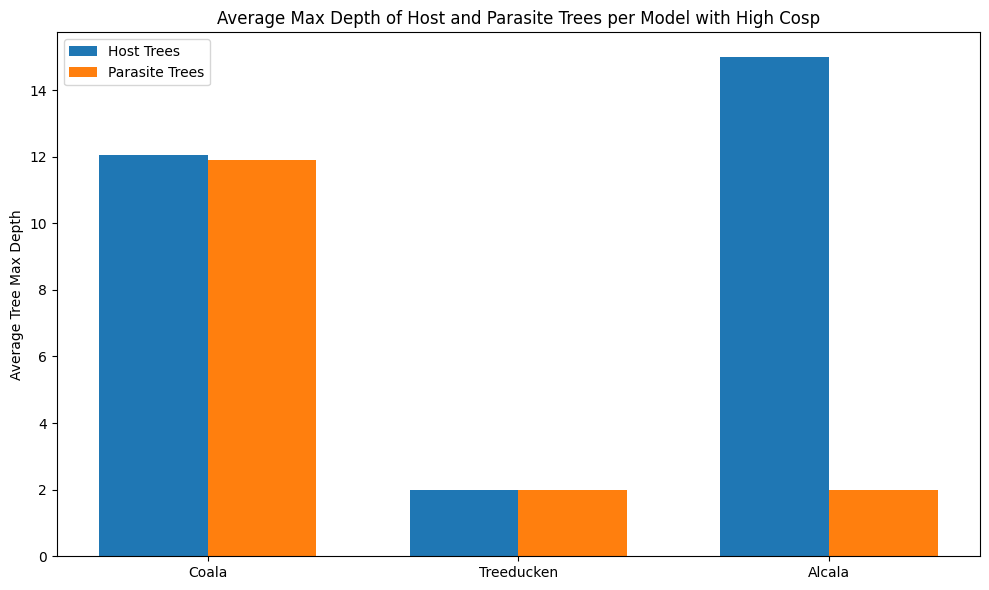

In [99]:
import matplotlib.pyplot as plt

# Compute average depths
host_depths = [
    average_host_tree_depth(datasets_coala_cosp),
    average_host_tree_depth(datasets_treeducken_cosp),
    average_host_tree_depth(datasets_alcala_cosp)
]

# Compute average depths
parasite_depths = [
    average_parasite_tree_depth(datasets_coala_cosp),
    average_parasite_tree_depth(datasets_treeducken_cosp),
    average_parasite_tree_depth(datasets_alcala_cosp)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_depths, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_depths, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree Max Depth')
plt.title('Average Max Depth of Host and Parasite Trees per Model with High Cosp')
plt.legend()
plt.tight_layout()
plt.show()

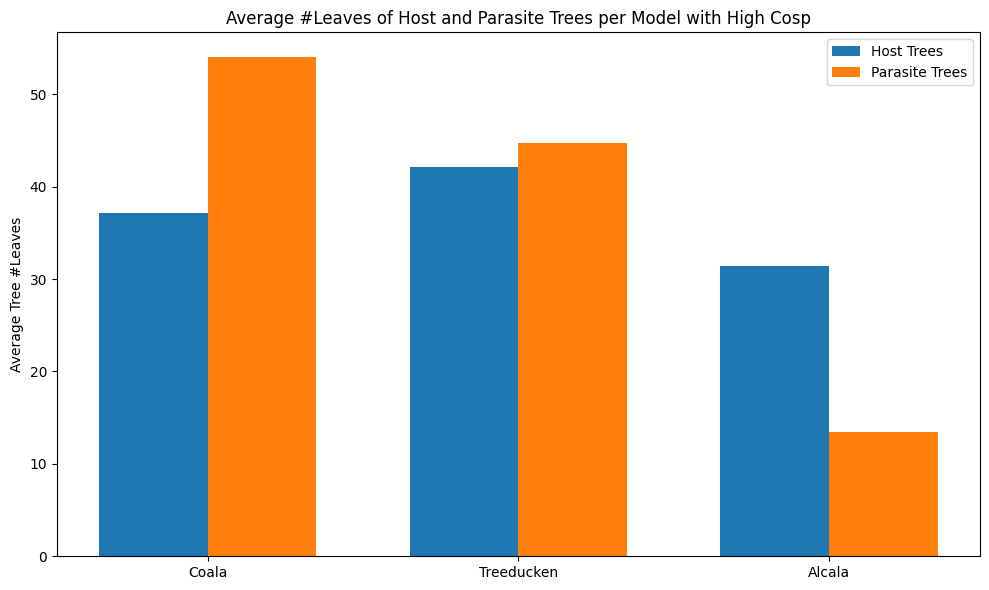

In [102]:
# Compute average depths
host_leaves = [
    average_host_tree_leaves(datasets_coala_cosp),
    average_host_tree_leaves(datasets_treeducken_cosp),
    average_host_tree_leaves(datasets_alcala_cosp)
]

# Compute average depths
parasite_leaves = [
    average_parasite_tree_leaves(datasets_coala_cosp),
    average_parasite_tree_leaves(datasets_treeducken_cosp),
    average_parasite_tree_leaves(datasets_alcala_cosp)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_leaves, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_leaves, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree #Leaves')
plt.title('Average #Leaves of Host and Parasite Trees per Model with High Cosp')
plt.legend()
plt.tight_layout()
plt.show()

## High Switch

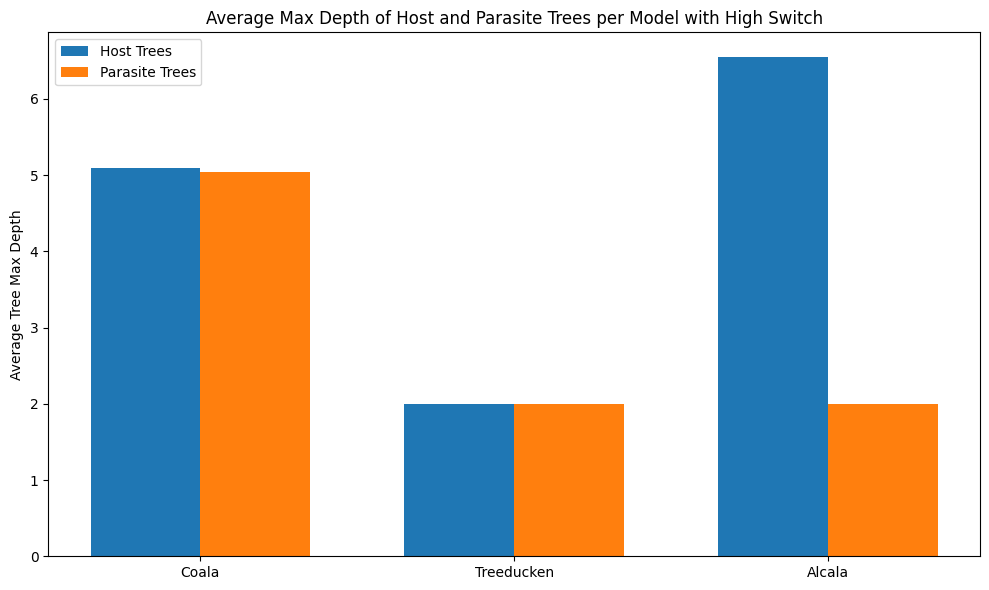

In [104]:
host_depths = [
    average_host_tree_depth(datasets_coala_switch),
    average_host_tree_depth(datasets_treeducken_switch),
    average_host_tree_depth(datasets_alcala_switch)
]

# Compute average depths
parasite_depths = [
    average_parasite_tree_depth(datasets_coala_switch),
    average_parasite_tree_depth(datasets_treeducken_switch),
    average_parasite_tree_depth(datasets_alcala_switch)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_depths, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_depths, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree Max Depth')
plt.title('Average Max Depth of Host and Parasite Trees per Model with High Switch')
plt.legend()
plt.tight_layout()
plt.show()

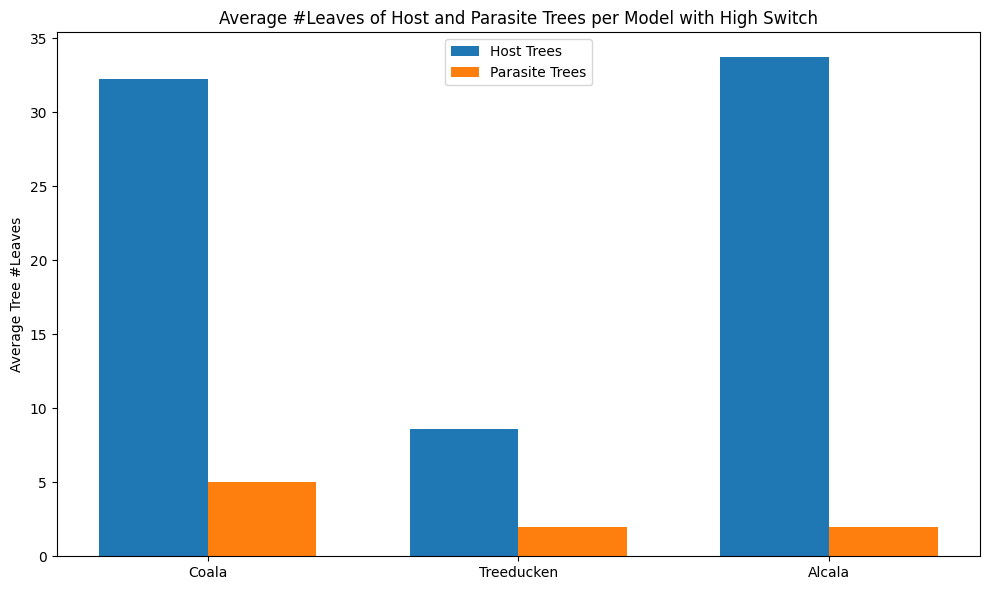

In [105]:
host_leaves = [
    average_host_tree_leaves(datasets_coala_switch),
    average_host_tree_leaves(datasets_treeducken_switch),
    average_host_tree_leaves(datasets_alcala_switch)
]

# Compute average depths
parasite_leaves = [
    average_parasite_tree_depth(datasets_coala_switch),
    average_parasite_tree_depth(datasets_treeducken_switch),
    average_parasite_tree_depth(datasets_alcala_switch)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_leaves, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_leaves, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree #Leaves')
plt.title('Average #Leaves of Host and Parasite Trees per Model with High Switch')
plt.legend()
plt.tight_layout()
plt.show()